In [3]:
import numpy as np
import torch
import torch.nn as nn

words = open('names.txt','r').read().splitlines()
chars = sorted(list(set("".join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

In [4]:
print(len(stoi))

27


### Dataset

In [5]:
def build_dataset(words):
    block_size = 3
    X, Y = [], []
    for w in words:
        context = [0]*block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            #print(''.join(itos[i] for i in context))
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape,Y.shape)
    return X,Y
import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])



torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [6]:
import torch.nn.functional as F

#F.one_hot(torch.tensor(5),num_classes=27).float() @ C

In [7]:
Xtr.shape, Ytr.shape

(torch.Size([182625, 3]), torch.Size([182625]))

In [8]:
########### PARAMATERS ##############
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,2),generator=g)
W1 = torch.randn((6,100),generator=g)
b1 = torch.randn(100,generator=g)
W2 = torch.randn((100,27),generator=g)
b2 = torch.randn((27),generator=g)
parameters = [C,W1,b1,W2,b2]


In [9]:
for p in parameters:
    p.requires_grad = True

In [10]:
lr = torch.linspace(-3,0,1000) #comme en numpy 
lre = 10**lr

In [21]:
#ler = []
#lossi = []
for i in range(10000):
    ix = torch.randint(0,Xtr.shape[0],(32,))
    emb = C[Xtr[ix]] # (32,3,2)
    h = torch.tanh(emb.view(-1,6) @ W1 + b1) # (32,100)
    logits = h @ W2 + b2 # (32,27)
    # counts = logits.exp()
    # probs = counts / counts.sum(1,keepdim=True)
    # loss = probs[torch.arange(32),Y].log().mean()
    loss = F.cross_entropy(logits,Ytr[ix]) #mieux numériquement (offset possibles) et plus efficace
    #lossi.append(loss.item())
    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    #lri = lre[i]
    #ler.append(lr[i].item())
    lri = 0.01
    for p in parameters:
        p.data += -lri*p.grad

In [12]:
import matplotlib.pyplot as plt
#plt.plot(ler,lossi)


In [22]:
emb = C[Xdev] # (32,3,2)
h = torch.tanh(emb.view(-1,6) @ W1 + b1) # (32,100)
logits = h @ W2 + b2 # (32,27)
loss = F.cross_entropy(logits,Ydev)
loss.item()

2.3294687271118164

In [14]:
# training split, dev splitn test split
# 80% 10% 10%

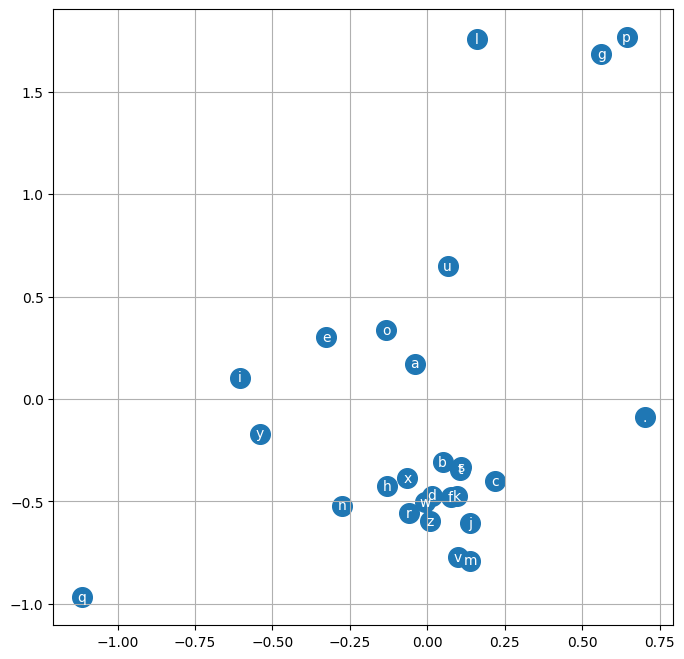

In [23]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(),C[i,1].item(),itos[i], ha="center", va="center", color="white")
plt.grid("minor")
